# Test Fine-tuning Results
Test the fine-tuned LIANet Creoss region performance to the local model perfomance

In [1]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from rasterio.windows import Window
# Add src to path
sys.path.insert(0, '/home/user/src')
import rasterio as rio
from datasets import BuildingBinaryRaster
from models.models_finetune import UNet, MicroUNet
from settings import *



from torchmetrics import MetricCollection

from metrics import multiclass_segmentation_metrics
# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
import os
import json
import random
import numpy as np
import rasterio as rio
from rasterio.windows import Window

TOP_DIR = "/home/user/data_shared/masks/BuildingFootprints"
DATA_DIR = "/home/user/data_shared"

labels_names = {
    "T31TFM": "T31TFM_20180920T104019_microsoft_buildings_2p5m.tif",
    "T32ULU": "T32ULU_20180917T103019_microsoft_buildings_2p5m.tif",
}

val_frac = 0.2
seed = 42

patch_size = 128
image_size = 10980
min_building_frac = 0.1
scale = 4

random.seed(seed)

for region in ["T31TFM", "T32ULU"]:
    valid_locs = []
    skipped_locs = 0

    label_path = os.path.join(TOP_DIR, labels_names[region])
    region_img_dir = os.path.join(DATA_DIR, region)

    time_strs = sorted([
        f for f in os.listdir(region_img_dir)
        if "BF" not in f
    ])

    with rio.open(label_path) as src_lbl:
        for y in range(0, image_size - patch_size, patch_size):
            for x in range(0, image_size - patch_size, patch_size):

                win_lbl = Window(
                    x * scale,
                    y * scale,
                    patch_size * scale,
                    patch_size * scale,
                )

                lbl = src_lbl.read(1, window=win_lbl)

                if lbl.dtype != np.bool_:
                    building_frac = (lbl > 0).mean()
                else:
                    building_frac = lbl.mean()

                if building_frac <= min_building_frac:
                    skipped_locs += 1
                    continue

                valid_locs.append({
                    "region": region,
                    "y": int(y),
                    "x": int(x),
                    "building_frac_160": float(building_frac),
                })

    # Split spatial locations first
    random.shuffle(valid_locs)

    n_val_locs = int(len(valid_locs) * val_frac)

    val_locs = valid_locs[:n_val_locs]
    train_locs = valid_locs[n_val_locs:]

    # Then expand each split over all dates
    train_samples = []
    val_samples = []

    for loc in train_locs:
        for sample_idx, time_str in enumerate(time_strs):
            train_samples.append({
                **loc,
                "sample_idx": int(sample_idx),
                "time_str": time_str,
            })

    for loc in val_locs:
        for sample_idx, time_str in enumerate(time_strs):
            val_samples.append({
                **loc,
                "sample_idx": int(sample_idx),
                "time_str": time_str,
            })

    # Optional shuffle within each split
    random.shuffle(train_samples)
    random.shuffle(val_samples)

    train_path = os.path.join(DATA_DIR, f"{region}_train_samples_10perc.json")
    val_path = os.path.join(DATA_DIR, f"{region}_val_samples_10perc.json")

    with open(train_path, "w") as f:
        json.dump(train_samples, f, indent=2)

    with open(val_path, "w") as f:
        json.dump(val_samples, f, indent=2)

    train_xy = set((s["x"], s["y"]) for s in train_samples)
    val_xy = set((s["x"], s["y"]) for s in val_samples)

    print(f"\nRegion: {region}")
    print(f"Valid locations: {len(valid_locs)}")
    print(f"Skipped locations: {skipped_locs}")
    print(f"Train locations: {len(train_xy)}")
    print(f"Validation locations: {len(val_xy)}")
    print(f"Location overlap: {len(train_xy & val_xy)}")
    print(f"Train samples: {len(train_samples)}")
    print(f"Validation samples: {len(val_samples)}")
    print(f"Saved train to: {train_path}")
    print(f"Saved val to: {val_path}")

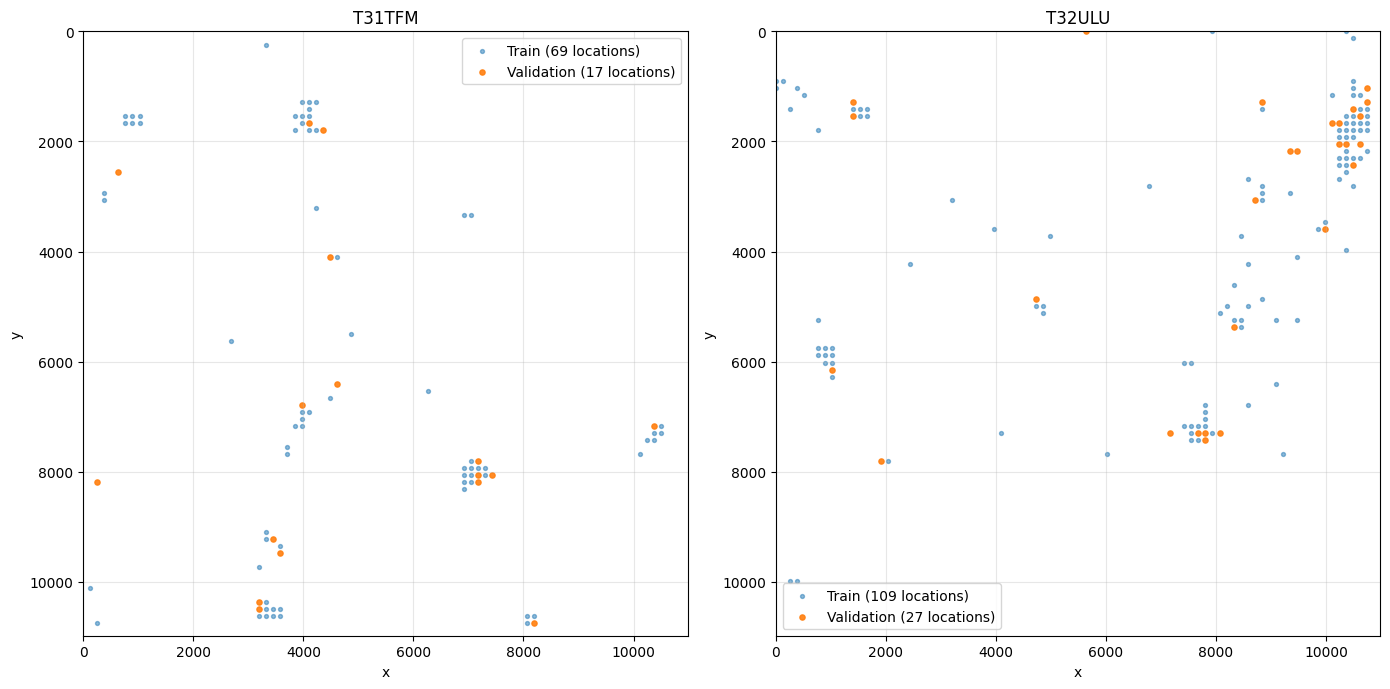

In [4]:
import os
import json
import matplotlib.pyplot as plt

DATA_DIR = "/home/user/data_shared"

regions = ["T31TFM", "T32ULU"]

image_size = 10980
patch_size = 128

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, region in zip(axes, regions):

    train_path = os.path.join(DATA_DIR, f"{region}_train_samples_10perc.json")
    val_path = os.path.join(DATA_DIR, f"{region}_val_samples_10perc.json")

    with open(train_path, "r") as f:
        train_samples = json.load(f)

    with open(val_path, "r") as f:
        val_samples = json.load(f)

    # Keep only unique spatial locations
    train_xy = sorted(set((s["x"], s["y"]) for s in train_samples))
    val_xy = sorted(set((s["x"], s["y"]) for s in val_samples))

    train_x = [p[0] for p in train_xy]
    train_y = [p[1] for p in train_xy]

    val_x = [p[0] for p in val_xy]
    val_y = [p[1] for p in val_xy]

    ax.scatter(
        train_x,
        train_y,
        s=8,
        alpha=0.5,
        label=f"Train ({len(train_xy)} locations)"
    )

    ax.scatter(
        val_x,
        val_y,
        s=14,
        alpha=0.9,
        label=f"Validation ({len(val_xy)} locations)"
    )

    ax.set_title(region)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    ax.set_xlim(0, image_size)
    ax.set_ylim(image_size, 0)  # flip y-axis to match image coordinates

    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


Region: T31TFM
Valid locations: 86
Skipped locations: 7139
Train locations: 69
Validation locations: 17
Location overlap: 0
Train samples: 1242
Validation samples: 306
Saved train to: /home/user/data_shared/T31TFM_train_samples_10perc.json
Saved val to: /home/user/data_shared/T31TFM_val_samples_10perc.json

Region: T32ULU
Valid locations: 136
Skipped locations: 7089
Train locations: 109
Validation locations: 27
Location overlap: 0
Train samples: 2071
Validation samples: 513
Saved train to: /home/user/data_shared/T32ULU_train_samples_10perc.json
Saved val to: /home/user/data_shared/T32ULU_val_samples_10perc.json


In [4]:
import json
from models.models_finetune import DownstreamModel
from models.LIANet import LIANetLight
import omegaconf, hydra

pretrained_model_path = "/home/user/results_shared/fourier_learned_4regions/2026-03-18_19-06-01"


def load_model(CKPT_PATH, other_task):
        # # Get config from checkpoint directory
    # finetune_config_path = os.path.join(os.path.dirname(CKPT_PATH), "config.json")
    # if os.path.exists(finetune_config_path):
    #     with open(finetune_config_path, 'r') as f:
    #         config = json.load(f)
    #     model_type = config.get("model_type", "replace_final_block")


    # Create DownstreamModel instance - CR finetuning
    # print(f"Loading DownstreamModel with adaptation strategy '{model_type}'...")
    model_finetune = DownstreamModel(
        model_path=pretrained_model_path,
        checkpoint_path_relative="model_checkpoints/latest_validation_checkpoint.pt",
        adaption_strategy="replace_final_block_4x",
        num_classes=num_classes[other_task],
        activation="none"
    )

    checkpoint = torch.load(CKPT_PATH, map_location=device)
    state_dict = checkpoint["model_state_dict"]
    if state_dict and all(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k[len("module."):]: v for k, v in state_dict.items()}

    model_finetune.load_state_dict(state_dict, strict=True)
    model_finetune = model_finetune.to(device)
    model_finetune.eval()
    print("✓ Model loaded successfully")
    return model_finetune

In [5]:
import os
import torch
import pandas as pd

from tqdm import tqdm
from torchmetrics import MetricCollection
from metrics import multiclass_segmentation_metrics


all_tasks_list = {
    "BFPBinary_joint_T31TFM",
    "BFPBinary_joint_T32ULU",
}

BATCH_SIZE = 16
NUM_WORKERS = 8

results_rows = []


for Target_region in all_tasks_list:
    other_tasks = all_tasks_list - {Target_region}

    val_dataset = BuildingBinaryRaster(
        top_dir=TOP_DIR[Target_region],
        s2_tiles=s2_tiles[Target_region],
        labels=labels[Target_region],
        train_val_key="val",
    )

    dataloader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        drop_last=False,
    )

    for source_region in other_tasks:
        model_dir = (
            f"/home/user/results_local/finetuning_results_BFPBinary/{source_region}/replace_final_block_4x_lr3e-05_batchsize8"
        )

        if not os.path.exists(model_dir):
            print(f"Model directory not found: {model_dir}. Skipping...")
            continue

        for run_name in sorted(os.listdir(model_dir)):
            ckpt_path = os.path.join(model_dir, run_name, "last.pt")

            if not os.path.exists(ckpt_path):
                print(f"Model directory not found: {model_dir}. Skipping...")
                continue

            model = load_model(ckpt_path, source_region)
            model.eval()

            list_of_metrics, _ = multiclass_segmentation_metrics(
                num_classes=num_classes[Target_region],
            )

            metrictracker = MetricCollection(list_of_metrics).to(device)

            with torch.no_grad():
                for batch in tqdm(
                    dataloader,
                    desc=f"{Target_region} | {source_region} | {run_name}",
                    leave=False,
                ):
                    x = batch["x_s2"].to(device)
                    y = batch["y_s2"].to(device)
                    label = batch["label"].to(device)
                    delta_days = batch["delta_days"].to(device)
                    target_tile = Target_region.split("_")[-1]
                    region_idx = 1 if target_tile == "T32ULU" else 2 if target_tile == "T31TFM" else None
                    _, pred = model(
                        delta_days,
                        x,
                        y,
                        torch.tensor([region_idx], device=device),
                    )

                    pred = getattr(pred, "output", pred)

                    if pred.dim() == 3:
                        pred = pred.unsqueeze(1)

                    metrictracker.update(pred, label)

            results = metrictracker.compute()

            row = {
                "target_region": Target_region,
                "source_region": source_region,
                "seed_or_run": run_name,
                "checkpoint_path": ckpt_path,
            }

            for metric_name, metric_value in results.items():
                row[metric_name] = float(metric_value.detach().cpu())

                results_rows.append(row)

            del model
            del metrictracker
            torch.cuda.empty_cache()

    del dataloader
    del val_dataset
    torch.cuda.empty_cache()


df_results = pd.DataFrame(results_rows)

df_results.to_csv(
    "BFPBinary_cr_transfer_results_all_target_regions.csv",
    index=False,
)

df_results

516 val samples loaded from /home/user/data_shared/T32ULU_val_samples_10perc.json
✓ Model loaded successfully


✓ Model loaded successfully


✓ Model loaded successfully


✓ Model loaded successfully


✓ Model loaded successfully


...

✓ Model loaded successfully


✓ Model loaded successfully


✓ Model loaded successfully


✓ Model loaded successfully


,target_region,source_region,seed_or_run,checkpoint_path,accuracy_macro,accuracy_micro,f1_macro,f1_micro,jaccard_macro,jaccard_micro,precision_macro,precision_micro,recall_macro,recall_micro
0,BFPBinary_joint_T32ULU,BFPBinary_joint_T31TFM,2026-05-11_14-13-41,/home/user/results_local/finetuning_results_BF...,0.697488,0.879451,0.727645,0.879451,0.613085,0.784840,0.781246,0.879451,0.697488,0.879451
1,BFPBinary_joint_T32ULU,BFPBinary_joint_T31TFM,2026-05-11_14-13-41,/home/user/results_local/finetuning_results_BF...,0.697488,0.879451,0.727645,0.879451,0.613085,0.784840,0.781246,0.879451,0.697488,0.879451
2,BFPBinary_joint_T32ULU,BFPBinary_joint_T31TFM,2026-05-11_14-13-41,/home/user/results_local/finetuning_results_BF...,0.697488,0.879451,0.727645,0.879451,0.613085,0.784840,0.781246,0.879451,0.697488,0.879451
3,BFPBinary_joint_T32ULU,BFPBinary_joint_T31TFM,2026-05-11_14-13-41,/home/user/results_local/finetuning_results_BF...,0.697488,0.879451,0.727645,0.879451,0.613085,0.784840,0.781246,0.879451,0.697488,0.879451
4,BFPBinary_joint_T32ULU,BFPBinary_joint_T31TFM,2026-05-11_14-13-41,/home/user/results_local/finetuning_results_BF...,0.697488,0.879451,0.727645,0.879451,0.613085,0.784840,0.781246,0.879451,0.697488,0.879451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,BFPBinary_joint_T31TFM,BFPBinary_joint_T32ULU,2026-05-11_15-56-55,/home/user/results_local/finetuning_results_BF...,0.689646,0.880671,0.725479,0.880671,0.611482,0.786785,0.800533,0.880671,0.689646,0.880671
96,BFPBinary_joint_T31TFM,BFPBinary_joint_T32ULU,2026-05-11_15-56-55,/home/user/results_local/finetuning_results_BF...,0.689646,0.880671,0.725479,0.880671,0.611482,0.786785,0.800533,0.880671,0.689646,0.880671
97,BFPBinary_joint_T31TFM,BFPBinary_joint_T32ULU,2026-05-11_15-56-55,/home/user/results_local/finetuning_results_BF...,0.689646,0.880671,0.725479,0.880671,0.611482,0.786785,0.800533,0.880671,0.689646,0.880671
98,BFPBinary_joint_T31TFM,BFPBinary_joint_T32ULU,2026-05-11_15-56-55,/home/user/results_local/finetuning_results_BF...,0.689646,0.880671,0.725479,0.880671,0.611482,0.786785,0.800533,0.880671,0.689646,0.880671


In [6]:
metadata_cols = [
    "target_region",
    "source_region",
    "seed_or_run",
    "checkpoint_path",
]

metric_cols = [
    col for col in df_results.columns
    if col not in metadata_cols
]

# Average over seeds/runs
df_seed_avg = (
    df_results
    .groupby(["target_region", "source_region"], as_index=False)[metric_cols]
    .mean()
)

# One result per target region
df_target_avg = (
    df_seed_avg
    .groupby(["target_region"], as_index=False)[metric_cols]
    .mean()
)

# Final result over all target regions
df_final_avg = (
    df_target_avg[metric_cols]
    .mean()
    .to_frame()
    .T
)

df_target_avg.to_csv("BFPBinary_transfer_results_avg_per_target_region.csv", index=False)
df_final_avg.to_csv("BFPBinary_transfer_results_final_avg_all_regions.csv", index=False)

df_target_avg, df_final_avg

(            target_region  accuracy_macro  accuracy_micro  f1_macro  f1_micro  \
 0  BFPBinary_joint_T31TFM        0.701688        0.880902  0.733956  0.880902   
 1  BFPBinary_joint_T32ULU        0.692301        0.879523  0.723996  0.879523   
 
    jaccard_macro  jaccard_micro  precision_macro  precision_micro  \
 0       0.619287       0.787154         0.794538         0.880902   
 1       0.609865       0.784955         0.784151         0.879523   
 
    recall_macro  recall_micro  
 0      0.701688      0.880902  
 1      0.692301      0.879523  ,
    accuracy_macro  accuracy_micro  f1_macro  f1_micro  jaccard_macro  \
 0        0.696994        0.880213  0.728976  0.880213       0.614576   
 
    jaccard_micro  precision_macro  precision_micro  recall_macro  recall_micro  
 0       0.786055         0.789344         0.880213      0.696994      0.880213  )

In [7]:
import json
from models.models_finetune import DownstreamModel
from models.LIANet import LIANetLight
import omegaconf, hydra

# pretrained_model_path = "/home/user/results_shared/fourier_learned_4regions/2026-03-18_19-06-01"

pretrained_model_path_list = {
    "T31TFM": "/home/user/results_shared/fourier_learned_T31TFM/2026-04-08_00-13-56",
    "T32ULU": "/home/user/results_shared/fourier_learned_T32ULU/2026-04-04_09-21-54",
}

def load_model(CKPT_PATH, other_task):

    pretrained_model_path = pretrained_model_path_list[other_task.split("_")[-1]]
    model_finetune = DownstreamModel(
        model_path=pretrained_model_path,
        checkpoint_path_relative="model_checkpoints/latest_validation_checkpoint.pt",
        adaption_strategy="replace_final_block_4x",
        num_classes=num_classes[other_task],
        activation="none"
    )

    checkpoint = torch.load(CKPT_PATH, map_location=device)
    state_dict = checkpoint["model_state_dict"]
    if state_dict and all(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k[len("module."):]: v for k, v in state_dict.items()}

    model_finetune.load_state_dict(state_dict, strict=True)
    model_finetune = model_finetune.to(device)
    model_finetune.eval()
    # print("✓ Model loaded successfully")
    return model_finetune

In [9]:
import os
import torch
import pandas as pd

from tqdm import tqdm
from torchmetrics import MetricCollection
from metrics import multiclass_segmentation_metrics


all_tasks_list = {
    "BFPBinary_local_T31TFM",
    "BFPBinary_local_T32ULU",
}

BATCH_SIZE = 16
NUM_WORKERS = 8

results_rows = []


for Target_region in all_tasks_list:
    source_region = Target_region

    val_dataset = BuildingBinaryRaster(
        top_dir=TOP_DIR[Target_region],
        s2_tiles=s2_tiles[Target_region],
        labels=labels[Target_region],
        train_val_key="val",
    )

    dataloader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        drop_last=False,
    )

    model_dir = (
        f"/home/user/results_local/finetuning_results_BFPBinary/{source_region}/replace_final_block_4x_lr3e-05_batchsize8"
    )

    if not os.path.exists(model_dir):
        print(f"Missing folder: {model_dir}")
        continue

    for run_name in sorted(os.listdir(model_dir)):
        ckpt_path = os.path.join(model_dir, run_name, "last.pt")

        if not os.path.exists(ckpt_path):
            continue

        model = load_model(ckpt_path, source_region)
        model.eval()

        list_of_metrics, _ = multiclass_segmentation_metrics(
            num_classes=num_classes[Target_region],
        )

        metrictracker = MetricCollection(list_of_metrics).to(device)

        with torch.no_grad():
            for batch in tqdm(
                dataloader,
                desc=f"{Target_region} | {run_name}",
                leave=False,
            ):
                x = batch["x_s2"].to(device)
                y = batch["y_s2"].to(device)
                label = batch["label"].to(device)
                delta_days = batch["delta_days"].to(device)

                _, pred = model(
                    delta_days,
                    x,
                    y,
                    torch.tensor([0], device=device),
                )

                pred = getattr(pred, "output", pred)

                if pred.dim() == 3:
                    pred = pred.unsqueeze(1)

                metrictracker.update(pred, label)

        results = metrictracker.compute()

        row = {
            "target_region": Target_region,
            "source_region": source_region,
            "seed_or_run": run_name,
            "checkpoint_path": ckpt_path,
        }

        for metric_name, metric_value in results.items():
            row[metric_name] = float(metric_value.detach().cpu())

        results_rows.append(row)

        del model
        del metrictracker
        torch.cuda.empty_cache()

    del dataloader
    del val_dataset
    torch.cuda.empty_cache()


df_local_results = pd.DataFrame(results_rows)

df_local_results.to_csv(
    "BFPBinary_local_baseline_results_all_regions.csv",
    index=False,
)

df_local_results

309 val samples loaded from /home/user/data_shared/T31TFM_val_samples_10perc.json


516 val samples loaded from /home/user/data_shared/T32ULU_val_samples_10perc.json


,target_region,source_region,seed_or_run,checkpoint_path,accuracy_macro,accuracy_micro,f1_macro,f1_micro,jaccard_macro,jaccard_micro,precision_macro,precision_micro,recall_macro,recall_micro
0,BFPBinary_local_T31TFM,BFPBinary_local_T31TFM,2026-05-11_14-14-07,/home/user/results_local/finetuning_results_BF...,0.733739,0.891640,0.765096,0.891640,0.651755,0.804469,0.816107,0.891640,0.733739,0.891640
1,BFPBinary_local_T31TFM,BFPBinary_local_T31TFM,2026-05-11_14-31-05,/home/user/results_local/finetuning_results_BF...,0.726796,0.891049,0.760393,0.891049,0.646968,0.803506,0.818171,0.891049,0.726796,0.891049
2,BFPBinary_local_T31TFM,BFPBinary_local_T31TFM,2026-05-11_14-47-19,/home/user/results_local/finetuning_results_BF...,0.732329,0.891596,0.764235,0.891596,0.650891,0.804396,0.816785,0.891596,0.732329,0.891596
3,BFPBinary_local_T31TFM,BFPBinary_local_T31TFM,2026-05-11_15-03-18,/home/user/results_local/finetuning_results_BF...,0.738134,0.892625,0.768659,0.892625,0.655560,0.806073,0.817131,0.892625,0.738134,0.892625
4,BFPBinary_local_T31TFM,BFPBinary_local_T31TFM,2026-05-11_15-19-24,/home/user/results_local/finetuning_results_BF...,0.731676,0.892623,0.764966,0.892623,0.651882,0.806070,0.821093,0.892623,0.731676,0.892623
5,BFPBinary_local_T32ULU,BFPBinary_local_T32ULU,2026-05-11_14-14-21,/home/user/results_local/finetuning_results_BF...,0.732679,0.887430,0.757570,0.887430,0.643262,0.797639,0.794058,0.887430,0.732679,0.887430
6,BFPBinary_local_T32ULU,BFPBinary_local_T32ULU,2026-05-11_14-38-42,/home/user/results_local/finetuning_results_BF...,0.714170,0.890255,0.749396,0.890255,0.636155,0.802215,0.813690,0.890255,0.714170,0.890255
7,BFPBinary_local_T32ULU,BFPBinary_local_T32ULU,2026-05-11_15-03-04,/home/user/results_local/finetuning_results_BF...,0.715542,0.887173,0.747066,0.887173,0.633119,0.797225,0.800843,0.887173,0.715542,0.887173
8,BFPBinary_local_T32ULU,BFPBinary_local_T32ULU,2026-05-11_15-26-46,/home/user/results_local/finetuning_results_BF...,0.656056,0.882626,0.697902,0.882626,0.588259,0.789910,0.829243,0.882626,0.656056,0.882626
9,BFPBinary_local_T32ULU,BFPBinary_local_T32ULU,2026-05-11_15-50-27,/home/user/results_local/finetuning_results_BF...,0.728230,0.890898,0.758690,0.890898,0.645266,0.803260,0.807847,0.890898,0.728230,0.890898


In [10]:
metadata_cols = [
    "target_region",
    "source_region",
    "seed_or_run",
    "checkpoint_path",
]

metric_cols = [
    col for col in df_local_results.columns
    if col not in metadata_cols
]

# Average over seeds/runs
df_local_seed_avg = (
    df_local_results
    .groupby(["target_region", "source_region"], as_index=False)[metric_cols]
    .mean()
)

# Final average over all local baselines
df_local_final_avg = (
    df_local_seed_avg[metric_cols]
    .mean()
    .to_frame()
    .T
)

df_local_seed_avg.to_csv(
    "BFPBinary_local_baseline_avg_per_region.csv",
    index=False,
)

df_local_final_avg.to_csv(
    "BFPBinary_local_baseline_final_avg_all_regions.csv",
    index=False,
)

df_local_seed_avg, df_local_final_avg

(            target_region           source_region  accuracy_macro  \
 0  BFPBinary_local_T31TFM  BFPBinary_local_T31TFM        0.732535   
 1  BFPBinary_local_T32ULU  BFPBinary_local_T32ULU        0.709336   
 
    accuracy_micro  f1_macro  f1_micro  jaccard_macro  jaccard_micro  \
 0        0.891907  0.764670  0.891907       0.651411       0.804903   
 1        0.887676  0.742125  0.887676       0.629212       0.798050   
 
    precision_macro  precision_micro  recall_macro  recall_micro  
 0         0.817857         0.891907      0.732535      0.891907  
 1         0.809136         0.887676      0.709336      0.887676  ,
    accuracy_macro  accuracy_micro  f1_macro  f1_micro  jaccard_macro  \
 0        0.720935        0.889791  0.753397  0.889791       0.640312   
 
    jaccard_micro  precision_macro  precision_micro  recall_macro  recall_micro  
 0       0.801476         0.813497         0.889791      0.720935      0.889791  )